# Exploratory Data Analysis (EDA) Tutorial — **Bivariate Data Analysis**  
## Correlation • Scatter Plots • *t*-tests • ANOVA • Linear Regression  
### Dataset: `salary_cleaned.csv` + `xtra_info.csv`

**What you will learn today (bivariate focus):**
1. Build a **master dataset** by joining two CSV files on a key (`USERID`)
2. Use **correlation** to measure association between numeric variables
3. Use **scatter plots** (and regression lines) to visualize numeric–numeric relationships
4. Use **two-sample *t*-tests** to compare the mean of a numeric variable between **two groups**
5. Use **ANOVA** to compare the mean of a numeric variable across **3+ groups**
6. Fit a **linear regression** model and interpret coefficients

## Setup and Import Libraries

In [15]:
# import libraries so your notebook can load data, plot graphs, run basic statistics, and display tables nicely
# NumPy (np): numerical computing (arrays, math, random numbers)
# Pandas (pd): data handling (DataFrames), reading CSVs, filtering, grouping, etc
import numpy as np
import pandas as pd

# Matplotlib (plt): the core plotting library (histograms, scatter, etc.)
# Seaborn (sns): higher-level plotting built on Matplotlib (nicer statistical plots like boxplot, heatmap, regplot).
import matplotlib.pyplot as plt
import seaborn as sns

# Imports SciPy’s statistics module (things like: correlation tests (Pearson r), t-tests (ttest_ind), ANOVA (f_oneway), and many more statistical functions).
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Fixes the random number generator so results are reproducible.
np.random.seed(42)

## 1) Load & join the datasets (IMPORTANT)

You have two files:
- `salary_cleaned.csv` (main table) — **28012 rows**
- `xtra_info.csv` (extra table) — **13404 rows**

Because they have **different numbers of rows**, you should **NOT** use `pd.concat(axis=1)`.

✅ Correct approach: **merge/join on a common key**: `USERID`.

We'll use a **left join**:
- keep all rows from salary data
- attach extra columns when `USERID` matches

In [16]:
# Mount Google Drive into Colab. Colab runs on a cloud VM. Your Drive is not available by default. When you run it, Colab will show an authentication link and ask you to authorize.
from google.colab import drive
drive.mount('/content/drive')

# Load CSV files into DataFrames (update the path if your folder name is different)
df_salary_cleaned = pd.read_csv('/content/drive/MyDrive/WIA1007/Dataset/salary_cleaned.csv') #load the csv dataset into a 'dataframe' df
df_xtra_info = pd.read_csv('/content/drive/MyDrive/WIA1007/Dataset/xtra_info.csv') #load the csv dataset into a 'dataframe' df

df_salary_cleaned.head()

df_xtra_info.head()

# Merge on USERID (left join keeps all salary rows)
df = df_salary_cleaned.merge(df_xtra_info, on="USERID", how="left")

print("MASTER df:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MASTER df: (32952, 19)


,USERID,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
0,0,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White,55000.0,0.0,NaN,NaN,NaN
1,1,25-34,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,United Kingdom,Unknown,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,68250.0,5000.0,2.695615,4250.0,125.0
2,2,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,34000.0,2000.0,NaN,NaN,NaN
3,3,25-34,Nonprofits,Program Manager,62000.0,3000.0,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,62000.0,3000.0,NaN,NaN,NaN
4,4,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,60000.0,7000.0,2.689383,12500.0,1133.0


### Quick Checks

In [17]:
# How many rows got matched?
matched = df["CGPA"].notna().sum() if "CGPA" in df.columns else 0
print("Rows with extra-info (non-missing CGPA):", matched)

# Missing values per extra column
extra_cols = [c for c in ["CGPA", "Salary_month_USD", "Special Bonus_GBP"] if c in df.columns]
df[extra_cols].isna().mean().round(3)

Rows with extra-info (non-missing CGPA): 13338


,0
CGPA,0.595
Salary_month_USD,0.595
Special Bonus_GBP,0.595


## 2) Prepare variables for analysis (convert bins to numbers)

In this dataset:
- `Age` is stored as bins (e.g., **25-34**)
- `Overall years of experience` is stored as bins (e.g., **11 - 20 years**)

For correlation/regression, we create approximate numeric versions:
- `Age_mid` = midpoint of the age bin
- `Exp_mid` = midpoint of experience bin

In [18]:
def midpoint_from_bin(text):
    """Convert a bin string into an approximate midpoint.
    Handles examples like '25-34', '11 - 20 years', '1 year or less', '41 years or more', '65 or over'.
    Returns np.nan if it cannot parse.
    """
    if pd.isna(text):
        return np.nan
    s = str(text).strip().lower()

    # common special cases
    if "under 18" in s:
        return 16.0
    if "65" in s and ("over" in s or "or over" in s):
        return 67.5
    if "41" in s and ("more" in s or "or more" in s):
        return 45.0
    if "1 year or less" in s:
        return 0.5

    # remove words
    s = s.replace("years", "").replace("year", "").replace(" ", "")

    # patterns like 25-34 or 11-20
    if "-" in s:
        parts = s.split("-")
        try:
            a = float(parts[0])
            b = float(parts[1])
            return (a + b) / 2.0
        except:
            return np.nan
    return np.nan

# Create numeric helper columns
if "Age" in df.columns:
    df["Age_mid"] = df["Age"].apply(midpoint_from_bin)

if "Overall years of experience" in df.columns:
    df["Exp_mid"] = df["Overall years of experience"].apply(midpoint_from_bin)

if "Years of experience in current job" in df.columns:
    df["Exp_current_mid"] = df["Years of experience in current job"].apply(midpoint_from_bin)

# Check
df[["Age", "Age_mid", "Overall years of experience", "Exp_mid"]].head(10)

,Age,Age_mid,Overall years of experience,Exp_mid
0,25-34,29.5,5-7 years,6.0
1,25-34,29.5,8 - 10 years,9.0
2,25-34,29.5,2 - 4 years,3.0
3,25-34,29.5,8 - 10 years,9.0
4,25-34,29.5,8 - 10 years,9.0
5,25-34,29.5,8 - 10 years,9.0
6,25-34,29.5,2 - 4 years,3.0
7,25-34,29.5,2 - 4 years,3.0
8,25-34,29.5,5-7 years,6.0
9,45-54,49.5,21 - 30 years,25.5


## 3) Correlation analysis (numeric–numeric)

Correlation answers: **When X increases, does Y tend to increase or decrease?**

- **Pearson correlation** (r) ranges from **-1 to +1**
  - r > 0 → positive association
  - r < 0 → negative association
  - r ≈ 0 → no linear association
- We'll also compute a **p-value** to test if correlation is statistically different from 0.

Note:
This block is preparing a clean numeric-only DataFrame for correlation, scatter plots, and other numeric analyses.

In [19]:
# Choose numeric columns we care about today
candidate_numeric = [
    "Salary_USD", "Compensation_USD", "Salary", "Compensation",
    "Age_mid", "Exp_mid", "Exp_current_mid",
    "CGPA", "Salary_month_USD", "Special Bonus_GBP"
]

num_cols = [c for c in candidate_numeric if c in df.columns]
df_num = df[num_cols].copy()

df_num.describe().T

,count,mean,std,min,25%,50%,75%,max
Salary_USD,32923.0,83322.304232,42183.956153,0.265000,52400.000000,73000.000000,105000.000000,241562.500000
Compensation_USD,32952.0,3659.805532,4391.436071,0.000000,0.000000,2000.000000,5000.000000,15625.000000
Salary,32923.0,84984.485466,42697.286948,1.000000,54000.000000,75000.000000,107500.000000,193250.000000
Compensation,32952.0,3699.974478,4406.243530,0.000000,0.000000,2000.000000,5000.000000,12500.000000
Age_mid,32952.0,36.199760,8.814332,16.000000,29.500000,39.500000,39.500000,67.500000
Exp_mid,32952.0,13.105502,8.273220,0.500000,6.000000,15.500000,15.500000,45.000000
Exp_current_mid,32952.0,9.588052,7.317042,0.500000,3.000000,6.000000,15.500000,45.000000
CGPA,13338.0,2.992978,0.574878,2.000039,2.501808,2.984469,3.484652,3.999992
Salary_month_USD,13338.0,6793.381548,2343.373443,3155.000000,4916.666667,6333.333333,8333.333333,12614.500000
Special Bonus_GBP,13338.0,2501.054431,1438.778929,0.000000,1265.000000,2503.500000,3761.750000,5000.000000


Note:
This code is doing correlation analysis between numeric variables and visualizing it as a heatmap.

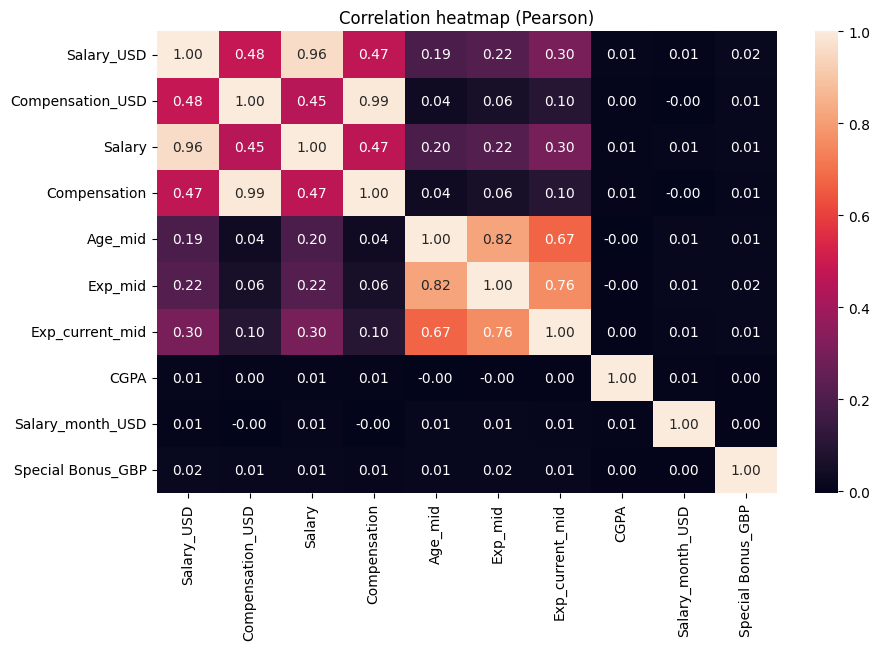

,Salary_USD,Compensation_USD,Salary,Compensation,Age_mid,Exp_mid,Exp_current_mid,CGPA,Salary_month_USD,Special Bonus_GBP
Salary_USD,1.000000,0.479035,0.957271,0.469019,0.194500,0.215922,0.302349,0.007606,0.007231,0.018266
Compensation_USD,0.479035,1.000000,0.450351,0.991011,0.036268,0.060241,0.098789,0.004882,-0.003100,0.014407
Salary,0.957271,0.450351,1.000000,0.465022,0.195803,0.216248,0.300427,0.006696,0.010387,0.011642
Compensation,0.469019,0.991011,0.465022,1.000000,0.036790,0.060895,0.099457,0.005610,-0.004211,0.011054
Age_mid,0.194500,0.036268,0.195803,0.036790,1.000000,0.817294,0.672276,-0.002773,0.014062,0.012386
Exp_mid,0.215922,0.060241,0.216248,0.060895,0.817294,1.000000,0.764611,-0.000158,0.013348,0.015387
Exp_current_mid,0.302349,0.098789,0.300427,0.099457,0.672276,0.764611,1.000000,0.003356,0.011185,0.011912
CGPA,0.007606,0.004882,0.006696,0.005610,-0.002773,-0.000158,0.003356,1.000000,0.006684,0.003429
Salary_month_USD,0.007231,-0.003100,0.010387,-0.004211,0.014062,0.013348,0.011185,0.006684,1.000000,0.002303
Special Bonus_GBP,0.018266,0.014407,0.011642,0.011054,0.012386,0.015387,0.011912,0.003429,0.002303,1.000000


In [20]:
# Correlation matrix (Pearson)
corr = df_num.corr(numeric_only=True)

# Creates a figure and draws a heatmap of the correlation matrix.
# annot=True prints the correlation values inside each cell.
# fmt=".2f" shows values with 2 decimal places.
# The heatmap makes it easy to spot strong relationships quickly.
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap (Pearson)")
plt.show()

# Displays the correlation matrix as a table as well (useful if you want exact values or to copy them).
corr

**What it’s trying to answer:**

“Which numeric variables move together?”

For example:

Does Salary increase with Experience?

Is Age related to Salary?

**How we should interpret the heatmap:**

*   Look for values close to +1 or -1 (strong relationships).
*   If Salary_USD and Compensation_USD are highly correlated (e.g., 0.95+), they likely contain similar information.
*   If Exp_mid has a positive correlation with Salary_USD, it suggests more experience is associated with higher salary (association, not causation).

That’s the purpose: quickly identify important pairwise relationships to explore further with scatter plots, tests, or regression.

In [21]:
# Correlation + p-value for a specific pair
def corr_with_pvalue(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna() # Builds a temporary table with both columns and removes rows where either x or y is missing. Correlation requires pairs of values

    # If fewer than 3 valid pairs remain, correlation is unreliable/undefined → return NaN
    if len(d) < 3:
        return np.nan, np.nan, len(d)
    r, p = stats.pearsonr(d["x"], d["y"])
    return r, p, len(d)

# This list defines the relationships we want to test
pairs = [("Exp_mid", "Salary_USD"), ("Age_mid", "Salary_USD"), ("CGPA", "Salary_month_USD")]

for a, b in pairs:
    if a in df.columns and b in df.columns:
        r, p, n = corr_with_pvalue(df[a], df[b])
        print(f"{a} vs {b}: r={r:.3f}, p={p:.3e}, n={n}")

Exp_mid vs Salary_USD: r=0.216, p=0.000e+00, n=32923
Age_mid vs Salary_USD: r=0.194, p=4.663e-278, n=32923
CGPA vs Salary_month_USD: r=0.007, p=4.402e-01, n=13338


**How to interpret the output:**

*r tells direction and strength:*

*   r = +0.40 → moderate positive association

*   r = -0.30 → moderate negative association

*   r ≈ 0 → no linear association

*p-value tells whether the observed correlation is unlikely under “no relationship”:*

*   p < 0.05 → statistically significant evidence correlation ≠ 0

*   p ≥ 0.05 → not enough evidence (could still be a weak relationship or too little data)

*n matters because:*

*   large n can make small correlations significant

*   small n makes results unstable

**That’s the goal**: quantify and test a few key bivariate relationships with proper handling of missing values.

## 4) Scatter plots (visualizing numeric–numeric relationships)

Scatter plots show:
- pattern (linear / non-linear)
- outliers
- clusters

We’ll use:
- `plt.scatter` (simple)
- `sns.regplot` (scatter + fitted line)

This code is building a reusable plotting function to visualize bivariate (two-variable) relationships using:

*   a scatter plot (each point is one person/row)
*   plus a best-fit regression line (to show the overall trend)

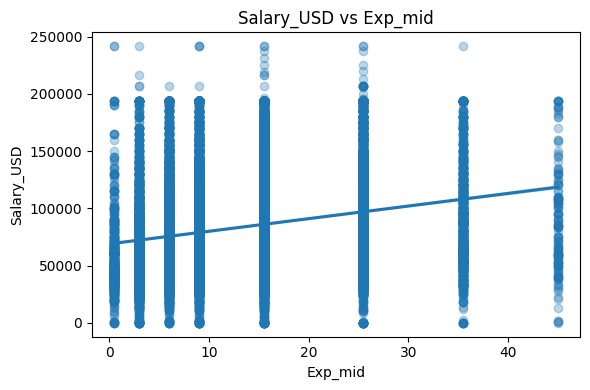

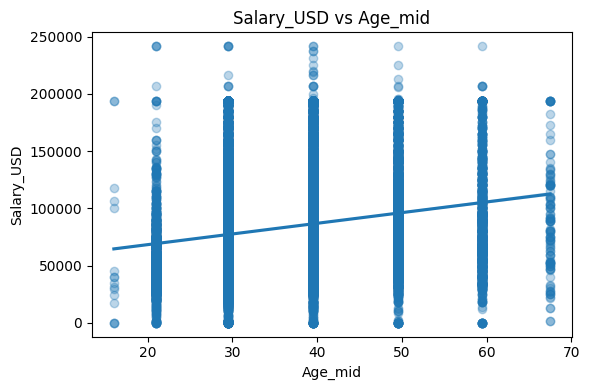

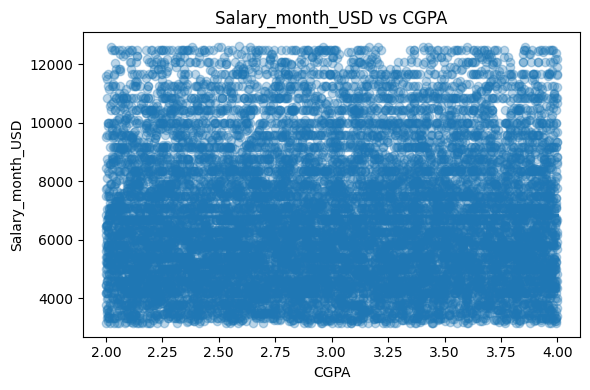

In [22]:
def scatter_with_line(x_col, y_col, data=df):
    d = data[[x_col, y_col]].dropna() # Removes rows where either value is missing (NaN), so plotting and regression work cleanly
    plt.figure(figsize=(6, 4)) # Creates a new figure with a fixed size
    sns.regplot(x=x_col, y=y_col, data=d, scatter_kws={"alpha": 0.3}) # regplot draws: scatter points, a linear regression line (default), alpha=0.3 makes points semi-transparent so dense regions don’t become a dark blob

    # Makes the plot readable and displays it
    plt.title(f"{y_col} vs {x_col}")
    plt.tight_layout()
    plt.show()

# Plot Salary vs Experience (midpoint) to see if salary tends to increase with experience
if "Exp_mid" in df.columns and "Salary_USD" in df.columns:
    scatter_with_line("Exp_mid", "Salary_USD")

# Plot Salary vs Age (midpoint) to see if salary tends to increase with age
if "Age_mid" in df.columns and "Salary_USD" in df.columns:
    scatter_with_line("Age_mid", "Salary_USD")

# Plot Monthly salary vs CGPA (academic performance vs pay) if those columns exist
if "CGPA" in df.columns and "Salary_month_USD" in df.columns:
    scatter_with_line("CGPA", "Salary_month_USD")

Here, we are automating “make a scatter plot + trend line for a chosen pair” and applying it to a few meaningful bivariate relationships in the salary dataset.

**From ONE scatter plot**:

*   Is the relationship positive or negative?

*   Is it roughly linear or not?

*   Are there outliers or clusters?

*   Does the fitted line suggest a meaningful trend?

## 5) Two-sample *t*-test (numeric vs two groups)

Use a *t*-test when:
- you have a numeric variable (e.g., Salary_USD)
- and a categorical variable with **two** groups (e.g., Woman vs Man)
- you want to test if the **means are different**

We'll use **Welch's t-test** (does not assume equal variances).

This block is running a two-sample t-test to check whether the average salary differs between Woman and Man (bivariate analysis: one numeric variable vs one binary categorical variable).

**What we’re trying to answer**:

Is the mean Salary_USD for Women significantly different from the mean Salary_USD for Men?

In [23]:
# Prepare a clean subset for Gender t-test
# We'll compare Woman vs Man only (ignore other categories for this specific test)

# Prevents errors if the dataset doesn’t have those columns
if "Gender" in df.columns and "Salary_USD" in df.columns:
    df_tt = df[df["Gender"].isin(["Woman", "Man"])][["Gender", "Salary_USD"]].dropna() # Keep only the two groups + the needed columns, remove missing values

    # Split salary into two separate groups
    g1 = df_tt[df_tt["Gender"] == "Woman"]["Salary_USD"]
    g2 = df_tt[df_tt["Gender"] == "Man"]["Salary_USD"]

    # Print sample size and mean for each group (descriptive stats)
    print("n(Woman) =", len(g1), " mean =", g1.mean())
    print("n(Man)   =", len(g2), " mean =", g2.mean())

    # Run Welch’s two-sample t-test
    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    # ttest_ind compares the means of two independent groups
    # equal_var=False means Welch’s t-test, which is safer because it does not assume equal variance between groups.

    # Output: t_stat = the test statistic.
    # p_val = probability of seeing a difference this large (or larger) if the true means were equal.
    print("Welch t-test: t =", t_stat, " p =", p_val)
else:
    print("Required columns missing: Gender and/or Salary_USD")

n(Woman) = 25656  mean = 79837.13996316653
n(Man)   = 6025  mean = 100457.57089875518
Welch t-test: t = -30.11148294511962  p = 1.2458823773134252e-188


**How to interpret the result**:

*   If p_val < 0.05: evidence that mean salary differs between Women and Men (statistically significant).

*   If p_val >= 0.05: not enough evidence to conclude a mean difference (based on this sample).

### Effect size (Cohen’s d)

P-value tells you if a difference is likely non-random.  
Effect size tells you **how big** the difference is.

This code is calculating Cohen’s d, which is an effect size for the difference between two groups (here: Women vs Men salaries).

*   A t-test tells you whether the means differ (significance).
*   Cohen’s d tells you how big that difference is (practical magnitude).

In [24]:
def cohens_d(a, b):
    # Removes missing values from both groups so calculations are clean
    a = a.dropna()
    b = b.dropna()
    na, nb = len(a), len(b)

    # Checks sample sizes. If either group has fewer than 2 values, variance can’t be computed reliably → return NaN
    if na < 2 or nb < 2:
        return np.nan

    sa2 = a.var(ddof=1)
    sb2 = b.var(ddof=1)

    # Computes sample variances of each group (ddof=1 makes it sample variance)
    sp = np.sqrt(((na - 1)*sa2 + (nb - 1)*sb2) / (na + nb - 2))

    # Computes the pooled standard deviation sp. This is a weighted average of the two group variances (weighted by sample sizes), then square-rooted.
    return (a.mean() - b.mean()) / sp # Returns Cohen’s d: It measures the mean difference in standard deviation units.

if "Gender" in df.columns and "Salary_USD" in df.columns:
    d = cohens_d(g1, g2)
    print("Cohen's d (Woman - Man):", d)

Cohen's d (Woman - Man): -0.49861660094549376


**How to interpret Cohen’s d (rule of thumb)**:

*   |d| ≈ 0.2 → small difference
*   |d| ≈ 0.5 → medium difference
*   |d| ≈ 0.8 → large difference

## 6) ANOVA (numeric vs 3+ groups)

ANOVA answers:
> Do **at least one** group mean differ from the others?

Example:
- Salary_USD compared across **Education level** (many categories)

This block is performing a one-way ANOVA to test whether average Salary_USD differs across multiple education levels (bivariate analysis: one numeric variable vs one categorical variable with 3+ groups), and then visualizes the comparison with a boxplot.

**What question are we trying to answer?**

Do people with different Education level have different mean salaries (Salary_USD)?

Groups used: ['College degree', "Master's degree", 'Some college', 'PhD', 'Professional degree (MD, JD, etc.)', 'High School']
ANOVA: F = 369.22114940567974  p = 0.0


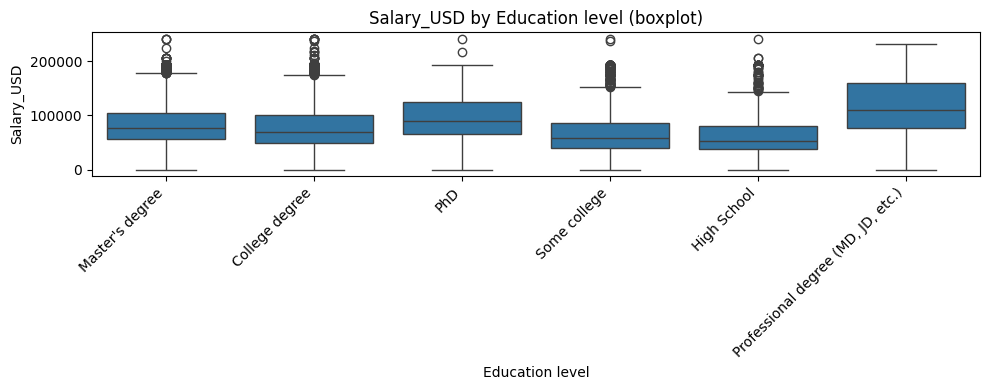

In [25]:
# One-way ANOVA: Salary_USD by Education level

# Identify the education column safely. Prevents errors if the column name is missing.
edu_col = "Education level" if "Education level" in df.columns else None

# Proceed only if required columns exist
if edu_col and "Salary_USD" in df.columns:
    df_aov = df[[edu_col, "Salary_USD"]].dropna() # Selects only education + salary. Keep only relevant columns and remove missing rows.

    # keep only groups with enough samples
    counts = df_aov[edu_col].value_counts() # Counts how many samples are in each education category.
    keep = counts[counts >= 30].index # Keeps only categories with at least 30 observations. Very small groups can produce unstable means/variances and make ANOVA less reliable.
    df_aov = df_aov[df_aov[edu_col].isin(keep)]

    # Build a list of salary arrays (one per education group). Creates something like: group 1 salaries (e.g., Bachelor’s), group 2 salaries (e.g., Master’s), group 3 salaries (e.g., PhD).
    groups = [df_aov[df_aov[edu_col] == g]["Salary_USD"] for g in keep]

    # Computes:
    # F-statistic: ratio of “between-group variance” to “within-group variance”
    # p-value: probability of getting this F (or larger) if all group means were equal
    f_stat, p_val = stats.f_oneway(*groups) # If p < 0.05, we say: there is evidence that salary differs by education level (at least one group differs)
    print("Groups used:", list(keep))
    print("ANOVA: F =", f_stat, " p =", p_val)

    # Visual: boxplot
    # Visualizes salary distributions per education group: median, spread, outliers
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_aov, x=edu_col, y="Salary_USD")
    plt.title("Salary_USD by Education level (boxplot)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns missing: Education level and/or Salary_USD")

ANOVA only tells you “at least one group differs”, not which pairs differ.

## 7) Linear Regression (bivariate + simple multivariate extension)

**Simple linear regression (bivariate)** example:
- Predict `Salary_USD` from `Exp_mid`

**Why regression?**
- Correlation tells association
- Regression gives a *predictive equation* and interpretable coefficient:
  - “For each +1 year of experience, salary changes by … (approximately)”

This code is fitting a simple linear regression to quantify the relationship between Experience and Salary, and then visualizing it.

**What question are we trying to answer?**

How does Salary_USD change as Exp_mid (experience in years) increases?

                            OLS Regression Results                            
Dep. Variable:             Salary_USD   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     1610.
Date:                Wed, 24 Dec 2025   Prob (F-statistic):               0.00
Time:                        07:23:00   Log-Likelihood:            -3.9655e+05
No. Observations:               32923   AIC:                         7.931e+05
Df Residuals:                   32921   BIC:                         7.931e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.888e+04    425.452    161.909      0.0

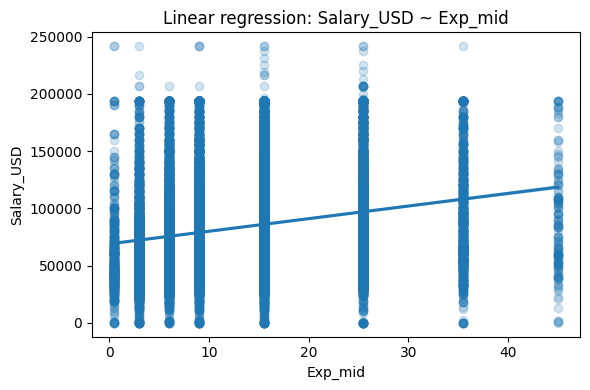

In [26]:
# Simple linear regression with statsmodels. Uses statsmodels because it gives interpretable statistical output.
try:
    import statsmodels.api as sm

    if "Salary_USD" in df.columns and "Exp_mid" in df.columns: # Runs only if both required columns exist.
        d = df[["Salary_USD", "Exp_mid"]].dropna() # Keeps only those two columns and removes missing rows. Regression cannot be fit with NaNs.
        X = sm.add_constant(d["Exp_mid"]) # Creates the predictor matrix X and Y.
        y = d["Salary_USD"]
        model = sm.OLS(y, X).fit() # Target variable (what we are predicting).
        print(model.summary()) # Prints a detailed report including: coef (intercept and slope), p-values (is the slope significantly different from 0?), R-squared (how much variance in salary the model explains), confidence intervals, etc.

        # Plot line
        plt.figure(figsize=(6,4))
        # Draws: scatter points (salary vs experience), the fitted regression line, alpha=0.2 makes points transparent so dense areas don’t hide patterns.
        sns.regplot(x="Exp_mid", y="Salary_USD", data=d, scatter_kws={"alpha":0.2})
        plt.title("Linear regression: Salary_USD ~ Exp_mid")
        plt.tight_layout()
        plt.show()
    else:
        print("Missing Salary_USD and/or Exp_mid for regression.")
except Exception as e:
    print("Regression skipped:", e) # If statsmodels isn’t available or something unexpected happens, the notebook won’t crash; it prints the reason.

**Interpret the result:**

We are doing bivariate modeling: fitting a line to estimate and test the relationship between experience and salary, then plotting it, we can visually confirm the trend and spot outliers.

# Summary (what we should remember)

### Techniques covered (bivariate)
- **Correlation**: strength & direction of linear association (r, p-value)
- **Scatter plot**: visualize patterns/outliers; `regplot` adds a line
- **Two-sample t-test**: compare means between two groups
- **ANOVA**: compare means across 3+ groups
- **Linear regression**: predictive relationship + interpretable coefficients